<a href="https://colab.research.google.com/github/tahaabe/RAG_project/blob/main/noise_labels.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Vérifier GPU
import torch
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"✓ Device: {device}")
if device == 'cuda':
    print(f"✓ GPU: {torch.cuda.get_device_name(0)}")
else:
    print("⚠️  Pas de GPU détecté - Active le GPU dans Runtime > Change runtime type")

✓ Device: cuda
✓ GPU: Tesla T4


In [12]:
import torch
import torchvision
import torchvision.transforms as transforms
import numpy as np
from torch.utils.data import Dataset, Subset

class QuickNoisyCIFAR10(Dataset):
    def __init__(self, root='./data', train=True, noise_type='symmetric',
                 noise_rate=0.2, subset_size=5000):

        self.transform = transforms.Compose([
            transforms.RandomCrop(32, padding=4),
            transforms.RandomHorizontalFlip(),
            transforms.ToTensor(),
            transforms.Normalize((0.4914, 0.4822, 0.4465),
                               (0.2023, 0.1994, 0.2010))
        ])

        dataset = torchvision.datasets.CIFAR10(root=root, train=train, download=True)

        # Subset aléatoire pour accélérer
        if train:
            indices = np.random.choice(len(dataset), subset_size, replace=False)
            dataset = Subset(dataset, indices)

        self.data = []
        self.targets = []
        for img, label in dataset:
            self.data.append(np.array(img))
            self.targets.append(label)

        self.data = np.array(self.data)
        self.targets = np.array(self.targets)
        self.clean_targets = self.targets.copy()

        if noise_rate > 0 and train:
            self._add_noise(noise_type, noise_rate)

    def _add_noise(self, noise_type, noise_rate):
        np.random.seed(42)
        n_samples = len(self.targets)
        n_noisy = int(noise_rate * n_samples)
        noisy_indices = np.random.choice(n_samples, n_noisy, replace=False)

        if noise_type == 'symmetric':
            for idx in noisy_indices:
                self.targets[idx] = np.random.randint(0, 10)
        elif noise_type == 'asymmetric':
            transition = {9: 1, 2: 0, 4: 7, 3: 5}
            for idx in noisy_indices:
                original = self.targets[idx]
                if original in transition:
                    self.targets[idx] = transition[original]

        actual_noise = np.mean(self.targets != self.clean_targets)
        print(f"✓ Taux de bruit réel : {actual_noise:.2%}")

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img = transforms.ToPILImage()(self.data[idx])
        if self.transform:
            img = self.transform(img)
        return img, self.targets[idx], idx

print("✓ Dataset class ready")

✓ Dataset class ready


In [13]:
import torch.nn as nn
import torchvision.models as models

def get_resnet18():
    model = models.resnet18(weights=None)
    model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
    model.maxpool = nn.Identity()
    model.fc = nn.Linear(model.fc.in_features, 10)
    return model

print("✓ Model ready")

✓ Model ready


In [14]:
import torch.optim as optim
from tqdm import tqdm

class QuickTrainer:
    def __init__(self, model, device='cuda'):
        self.model = model.to(device)
        self.device = device
        self.criterion = nn.CrossEntropyLoss()

    def train_epoch(self, loader, optimizer):
        self.model.train()
        total_loss = 0
        correct = 0
        total = 0

        for inputs, targets, _ in tqdm(loader, desc='Training', leave=False):
            inputs, targets = inputs.to(self.device), targets.to(self.device)

            optimizer.zero_grad()
            outputs = self.model(inputs)
            loss = self.criterion(outputs, targets)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()

        return total_loss/len(loader), 100.*correct/total

    def test(self, loader):
        self.model.eval()
        correct = 0
        total = 0

        with torch.no_grad():
            for inputs, targets in loader:
                inputs, targets = inputs.to(self.device), targets.to(self.device)
                outputs = self.model(inputs)
                _, predicted = outputs.max(1)
                total += targets.size(0)
                correct += predicted.eq(targets).sum().item()

        return 100.*correct/total

print("✓ Trainer ready")

✓ Trainer ready


In [16]:
import matplotlib.pyplot as plt

def run_experiment(noise_type='symmetric', noise_rate=0.2, epochs=20):
    print(f"\n{'='*60}")
    print(f"Expérience: {noise_type} noise, rate={noise_rate}")
    print(f"{'='*60}\n")

    # Data
    train_dataset = QuickNoisyCIFAR10(
        train=True,
        noise_type=noise_type,
        noise_rate=noise_rate,
        subset_size=5000
    )

    test_transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
    ])
    test_dataset = torchvision.datasets.CIFAR10(
        root='./data', train=False, download=True, transform=test_transform
    )

    train_loader = torch.utils.data.DataLoader(
        train_dataset, batch_size=128, shuffle=True, num_workers=2
    )
    test_loader = torch.utils.data.DataLoader(
        test_dataset, batch_size=128, shuffle=False, num_workers=2
    )

    # Model
    model = get_resnet18()
    trainer = QuickTrainer(model, device='cuda')

    # Train
    optimizer = optim.SGD(model.parameters(), lr=0.1, momentum=0.9, weight_decay=5e-4)
    scheduler = optim.lr_scheduler.MultiStepLR(optimizer, milestones=[10, 15], gamma=0.1)

    history = {'train_loss': [], 'train_acc': [], 'test_acc': []}

    for epoch in range(epochs):
        print(f"\nEpoch {epoch+1}/{epochs}")
        train_loss, train_acc = trainer.train_epoch(train_loader, optimizer)
        test_acc = trainer.test(test_loader)
        scheduler.step()

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['test_acc'].append(test_acc)

        print(f"Loss: {train_loss:.4f} | Train: {train_acc:.2f}% | Test: {test_acc:.2f}%")

    # Plot
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.plot(history['train_loss'])
    ax1.set_title('Training Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.grid(True)

    ax2.plot(history['train_acc'], label='Train')
    ax2.plot(history['test_acc'], label='Test')
    ax2.set_title('Accuracy')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy (%)')
    ax2.legend()
    ax2.grid(True)

    plt.suptitle(f'{noise_type.capitalize()} Noise ({noise_rate*100}%)')
    plt.tight_layout()
    plt.show()

    print(f"\n✓ Final Test Accuracy: {history['test_acc'][-1]:.2f}%")
    return history

print("✓ Experiment function ready")

✓ Experiment function ready



Expérience: symmetric noise, rate=0.0


Epoch 1/20


Loss: 3.4072 | Train: 11.80% | Test: 13.57%

Epoch 2/20


Loss: 2.2587 | Train: 13.38% | Test: 16.45%

Epoch 3/20


Loss: 2.0701 | Train: 19.48% | Test: 21.71%

Epoch 4/20


Loss: 1.9826 | Train: 22.06% | Test: 22.98%

Epoch 5/20


...

Loss: 1.4553 | Train: 46.14% | Test: 46.30%

Epoch 17/20


Loss: 1.4428 | Train: 45.78% | Test: 46.09%

Epoch 18/20


Loss: 1.4456 | Train: 46.38% | Test: 46.34%

Epoch 19/20


Loss: 1.4574 | Train: 46.34% | Test: 46.23%

Epoch 20/20


Loss: 1.4323 | Train: 45.60% | Test: 46.25%


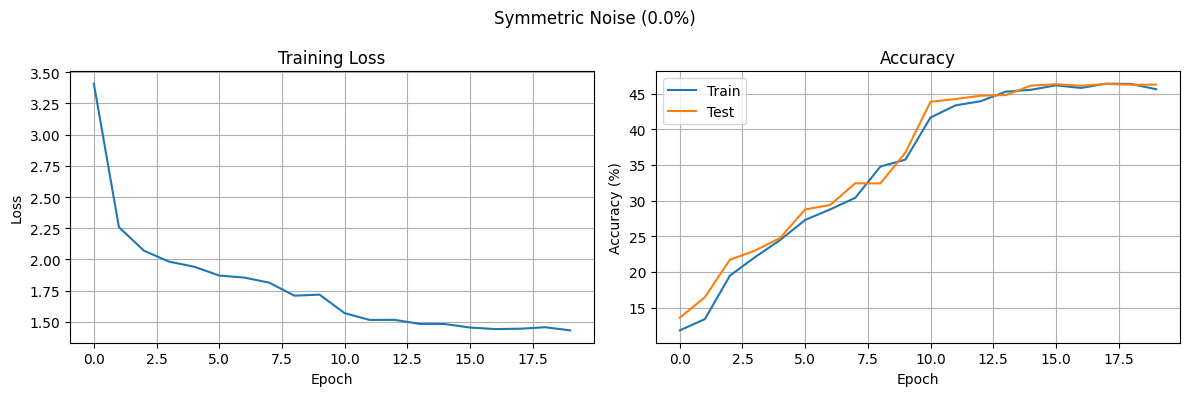


✓ Final Test Accuracy: 46.25%

Expérience: symmetric noise, rate=0.2

✓ Taux de bruit réel : 18.06%

Epoch 1/20


Loss: 4.5389 | Train: 10.84% | Test: 9.07%

Epoch 2/20


Loss: 2.3158 | Train: 10.56% | Test: 10.01%

Epoch 3/20


Loss: 2.3031 | Train: 10.86% | Test: 10.00%

Epoch 4/20


Loss: 2.3107 | Train: 10.20% | Test: 10.07%

Epoch 5/20


...

Loss: 2.1221 | Train: 18.10% | Test: 19.05%

Epoch 17/20


Loss: 2.1222 | Train: 18.56% | Test: 19.25%

Epoch 18/20


Loss: 2.1143 | Train: 18.56% | Test: 20.34%

Epoch 19/20


Loss: 2.1116 | Train: 19.02% | Test: 20.54%

Epoch 20/20


Loss: 2.1142 | Train: 18.82% | Test: 20.47%


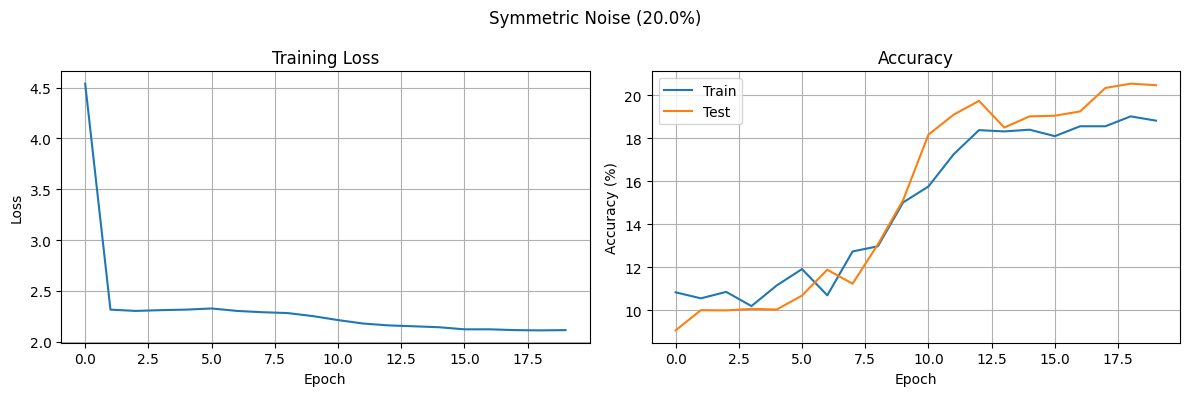


✓ Final Test Accuracy: 20.47%

Expérience: symmetric noise, rate=0.4

✓ Taux de bruit réel : 35.80%

Epoch 1/20


Loss: 3.7055 | Train: 9.80% | Test: 10.74%

Epoch 2/20


Loss: 2.3251 | Train: 10.16% | Test: 10.94%

Epoch 3/20


Loss: 2.3009 | Train: 12.04% | Test: 11.75%

Epoch 4/20


Loss: 2.2986 | Train: 12.44% | Test: 12.23%

Epoch 5/20


...

Loss: 2.1961 | Train: 18.52% | Test: 21.36%

Epoch 17/20


Loss: 2.2006 | Train: 17.78% | Test: 21.61%

Epoch 18/20


Loss: 2.1941 | Train: 18.58% | Test: 21.07%

Epoch 19/20


Loss: 2.1963 | Train: 18.02% | Test: 21.48%

Epoch 20/20


Loss: 2.2023 | Train: 18.16% | Test: 21.78%


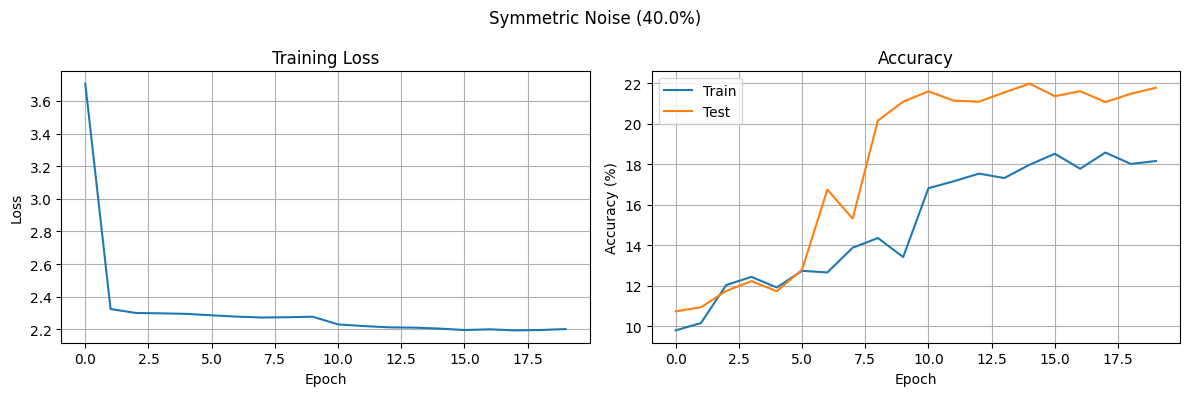


✓ Final Test Accuracy: 21.78%

Expérience: asymmetric noise, rate=0.2

✓ Taux de bruit réel : 8.42%

Epoch 1/20


Loss: 2.7703 | Train: 15.60% | Test: 20.39%

Epoch 2/20


Loss: 2.1667 | Train: 20.56% | Test: 21.27%

Epoch 3/20


Loss: 1.9549 | Train: 27.26% | Test: 22.28%

Epoch 4/20


Loss: 1.9204 | Train: 29.50% | Test: 27.65%

Epoch 5/20


...

Loss: 1.4015 | Train: 48.04% | Test: 46.12%

Epoch 17/20


Loss: 1.4054 | Train: 48.52% | Test: 46.80%

Epoch 18/20


Loss: 1.4079 | Train: 48.44% | Test: 46.89%

Epoch 19/20


Loss: 1.4158 | Train: 49.04% | Test: 46.95%

Epoch 20/20


Loss: 1.4069 | Train: 48.74% | Test: 47.23%


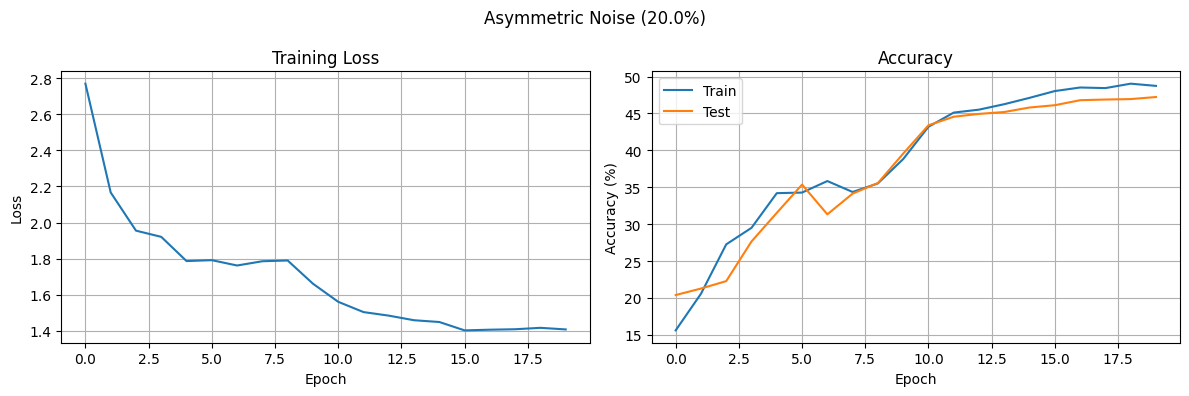


✓ Final Test Accuracy: 47.23%


In [18]:
# Expérience 1: Pas de bruit
results_clean = run_experiment(noise_type='symmetric', noise_rate=0.0, epochs=20)

# Expérience 2: Bruit symétrique 20%
results_sym20 = run_experiment(noise_type='symmetric', noise_rate=0.2, epochs=20)

# Expérience 3: Bruit symétrique 40%
results_sym40 = run_experiment(noise_type='symmetric', noise_rate=0.4, epochs=20)

# Expérience 4: Bruit asymétrique 20%
results_asym20 = run_experiment(noise_type='asymmetric', noise_rate=0.2, epochs=20)

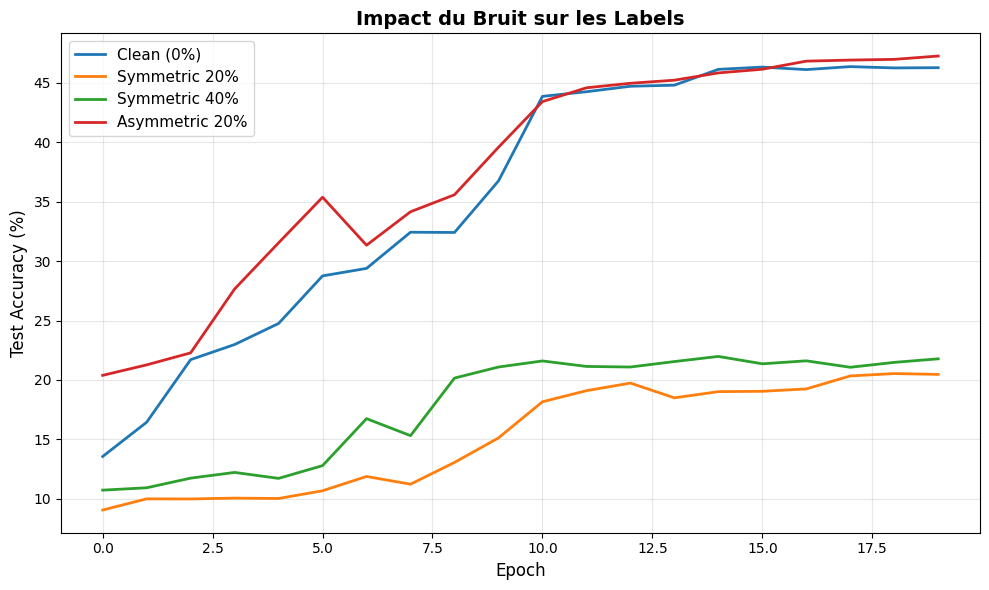


RÉSUMÉ DES RÉSULTATS (Test Accuracy finale)
Clean (0%)        : 46.25%
Symmetric 20%     : 20.47%
Symmetric 40%     : 21.78%
Asymmetric 20%    : 47.23%


In [19]:
# Comparaison des résultats
plt.figure(figsize=(10, 6))

plt.plot(results_clean['test_acc'], label='Clean (0%)', linewidth=2)
plt.plot(results_sym20['test_acc'], label='Symmetric 20%', linewidth=2)
plt.plot(results_sym40['test_acc'], label='Symmetric 40%', linewidth=2)
plt.plot(results_asym20['test_acc'], label='Asymmetric 20%', linewidth=2)

plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Test Accuracy (%)', fontsize=12)
plt.title('Impact du Bruit sur les Labels', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Résumé
print("\n" + "="*60)
print("RÉSUMÉ DES RÉSULTATS (Test Accuracy finale)")
print("="*60)
print(f"Clean (0%)        : {results_clean['test_acc'][-1]:.2f}%")
print(f"Symmetric 20%     : {results_sym20['test_acc'][-1]:.2f}%")
print(f"Symmetric 40%     : {results_sym40['test_acc'][-1]:.2f}%")
print(f"Asymmetric 20%    : {results_asym20['test_acc'][-1]:.2f}%")
print("="*60)

noise robust


In [20]:
import torch.nn.functional as F
import torch.nn as nn

class LabelSmoothingLoss(nn.Module):

    def __init__(self, num_classes=10, smoothing=0.1):
        super().__init__()

        self.num_classes = num_classes
        self.smoothing = smoothing
        self.confidence = 1.0 - smoothing

    def forward(self, pred, target):

        log_probs = F.log_softmax(pred, dim=1)

        with torch.no_grad():

            true_dist = torch.zeros_like(log_probs)

            true_dist.fill_(
                self.smoothing / (self.num_classes - 1)
            )

            true_dist.scatter_(
                1,
                target.unsqueeze(1),
                self.confidence
            )

        loss = torch.mean(
            torch.sum(-true_dist * log_probs, dim=1)
        )

        return loss

new trainer


In [21]:
class LabelSmoothingTrainer:

    def __init__(self, model, smoothing=0.1, device='cuda'):

        self.model = model.to(device)
        self.device = device

        self.criterion = LabelSmoothingLoss(
            num_classes=10,
            smoothing=smoothing
        )

    def train_epoch(self, loader, optimizer):

        self.model.train()

        total_loss = 0
        correct = 0
        total = 0

        for inputs, targets, _ in tqdm(loader, desc='Training', leave=False):

            inputs = inputs.to(self.device)
            targets = targets.to(self.device)

            optimizer.zero_grad()

            outputs = self.model(inputs)

            loss = self.criterion(outputs, targets)

            loss.backward()

            optimizer.step()

            total_loss += loss.item()

            _, predicted = outputs.max(1)

            total += targets.size(0)

            correct += predicted.eq(targets).sum().item()

        return total_loss / len(loader), 100. * correct / total

    def test(self, loader):

        self.model.eval()

        correct = 0
        total = 0

        with torch.no_grad():

            for inputs, targets in loader:

                inputs = inputs.to(self.device)
                targets = targets.to(self.device)

                outputs = self.model(inputs)

                _, predicted = outputs.max(1)

                total += targets.size(0)

                correct += predicted.eq(targets).sum().item()

        return 100. * correct / total

In [27]:
def run_label_smoothing_experiment(
    noise_type='symmetric',
    noise_rate=0.4,
    smoothing=0.1,
    epochs=20,
    device=None # Add device as a parameter
):

    print(f"\n{'='*60}")
    print("LABEL SMOOTHING")
    print(f"{'='*60}\n")

    train_dataset = QuickNoisyCIFAR10(
        train=True,
        noise_type=noise_type,
        noise_rate=noise_rate,
        subset_size=5000
    )

    test_transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(
            (0.4914, 0.4822, 0.4465),
            (0.2023, 0.1994, 0.2010)
        )
    ])

    test_dataset = torchvision.datasets.CIFAR10(
        root='./data',
        train=False,
        download=True,
        transform=test_transform
    )

    train_loader = torch.utils.data.DataLoader(
        train_dataset,
        batch_size=128,
        shuffle=True,
        num_workers=2
    )

    test_loader = torch.utils.data.DataLoader(
        test_dataset,
        batch_size=128,
        shuffle=False,
        num_workers=2
    )

    model = get_resnet18()

    # Ensure device is set, default to 'cuda' if not provided
    if device is None:
        device = 'cuda' if torch.cuda.is_available() else 'cpu'

    trainer = LabelSmoothingTrainer(
        model,
        smoothing=smoothing,
        device=device
    )

    optimizer = optim.SGD(
        model.parameters(),
        lr=0.1,
        momentum=0.9,
        weight_decay=5e-4
    )

    scheduler = optim.lr_scheduler.MultiStepLR(
        optimizer,
        milestones=[10, 15],
        gamma=0.1
    )

    history = {
        'train_loss': [],
        'train_acc': [],
        'test_acc': []
    }

    for epoch in range(epochs):

        print(f"\nEpoch {epoch+1}/{epochs}")

        train_loss, train_acc = trainer.train_epoch(
            train_loader,
            optimizer
        )

        test_acc = trainer.test(test_loader)

        scheduler.step()

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['test_acc'].append(test_acc)

        print(
            f"Loss: {train_loss:.4f} | "
            f"Train: {train_acc:.2f}% | "
            f"Test: {test_acc:.2f}%"
        )

    return history

In [35]:
import torch
device = 'cuda' if torch.cuda.is_available() else 'cpu'

results_ls_40 = run_label_smoothing_experiment(
    noise_type='symmetric',
    noise_rate=0.4,
    smoothing=0.1,
    epochs=20,
    device=device # Pass the global device variable
)


LABEL SMOOTHING

✓ Taux de bruit réel : 36.18%

Epoch 1/20


Loss: 3.4873 | Train: 10.48% | Test: 7.64%

Epoch 2/20


Loss: 2.3051 | Train: 11.12% | Test: 15.89%

Epoch 3/20


Loss: 2.2848 | Train: 13.74% | Test: 14.12%

Epoch 4/20


Loss: 2.2614 | Train: 14.14% | Test: 19.51%

Epoch 5/20


...

Loss: 2.2000 | Train: 20.38% | Test: 25.35%

Epoch 17/20


Loss: 2.1962 | Train: 20.32% | Test: 25.45%

Epoch 18/20


Loss: 2.1941 | Train: 20.28% | Test: 25.61%

Epoch 19/20


Loss: 2.1930 | Train: 20.52% | Test: 25.45%

Epoch 20/20


Loss: 2.1947 | Train: 20.42% | Test: 25.53%


In [39]:
results_ls_20 = run_label_smoothing_experiment(
    noise_type='symmetric',
    noise_rate=0.2,
    smoothing=0.1,
    epochs=20,
    device=device # Pass the global device variable
)


LABEL SMOOTHING

✓ Taux de bruit réel : 18.20%

Epoch 1/20


Loss: 3.5129 | Train: 10.88% | Test: 15.07%

Epoch 2/20


Loss: 2.3662 | Train: 12.84% | Test: 14.75%

Epoch 3/20


Loss: 2.3049 | Train: 12.48% | Test: 16.28%

Epoch 4/20


Loss: 2.2366 | Train: 17.62% | Test: 19.88%

Epoch 5/20


...

Loss: 2.0664 | Train: 29.48% | Test: 34.47%

Epoch 17/20


Loss: 2.0648 | Train: 29.64% | Test: 34.42%

Epoch 18/20


Loss: 2.0539 | Train: 29.54% | Test: 34.02%

Epoch 19/20


Loss: 2.0632 | Train: 29.44% | Test: 34.34%

Epoch 20/20


Loss: 2.0600 | Train: 29.46% | Test: 33.82%


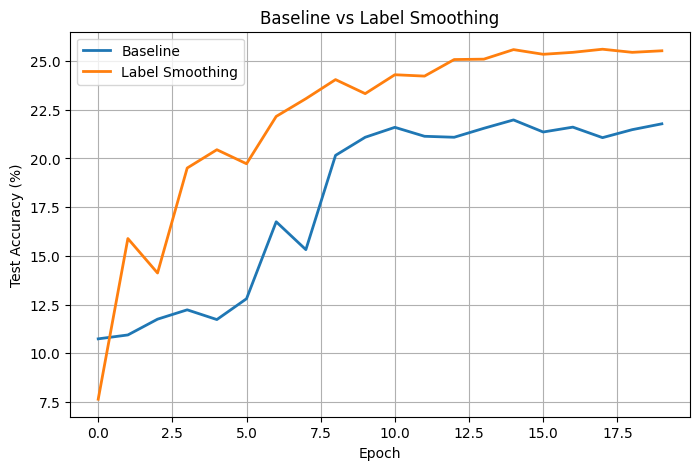

In [36]:
plt.figure(figsize=(8,5))

plt.plot(
    results_sym40['test_acc'],
    label='Baseline',
    linewidth=2
)

plt.plot(
    results_ls_40['test_acc'],
    label='Label Smoothing',
    linewidth=2
)

plt.xlabel('Epoch')
plt.ylabel('Test Accuracy (%)')

plt.title('Baseline vs Label Smoothing')

plt.legend()

plt.grid(True)

plt.show()

Sample Reweighting

In [31]:
import torch.nn as nn

class ReweightingTrainer:
    def __init__(self, model, device='cuda'):
        self.model = model.to(device)
        self.device = device

        # IMPORTANT: reduction='none'
        self.criterion = nn.CrossEntropyLoss(reduction='none')

    def train_epoch(self, loader, optimizer):
        self.model.train()

        total_loss = 0
        correct = 0
        total = 0

        for inputs, targets, _ in tqdm(loader, desc='Training', leave=False):

            inputs = inputs.to(self.device)
            targets = targets.to(self.device)

            optimizer.zero_grad()

            outputs = self.model(inputs)

            # Per-sample losses
            losses = self.criterion(outputs, targets)

            # Compute weights
            weights = torch.exp(-losses.detach())

            # Weighted loss
            loss = (weights * losses).mean()

            loss.backward()
            optimizer.step()

            total_loss += loss.item()

            _, predicted = outputs.max(1)

            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()

        return total_loss / len(loader), 100. * correct / total

    def test(self, loader):

        self.model.eval()

        correct = 0
        total = 0

        with torch.no_grad():

            for inputs, targets in loader:

                inputs = inputs.to(self.device)
                targets = targets.to(self.device)

                outputs = self.model(inputs)

                _, predicted = outputs.max(1)

                total += targets.size(0)
                correct += predicted.eq(targets).sum().item()

        return 100. * correct / total

In [32]:
def run_reweighting_experiment(noise_type='symmetric',
                               noise_rate=0.2,
                               epochs=20):

    print(f"\n{'='*60}")
    print(f"Reweighting: {noise_type} noise, rate={noise_rate}")
    print(f"{'='*60}\n")

    # DATA
    train_dataset = QuickNoisyCIFAR10(
        train=True,
        noise_type=noise_type,
        noise_rate=noise_rate,
        subset_size=5000
    )

    test_transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(
            (0.4914, 0.4822, 0.4465),
            (0.2023, 0.1994, 0.2010)
        )
    ])

    test_dataset = torchvision.datasets.CIFAR10(
        root='./data',
        train=False,
        download=True,
        transform=test_transform
    )

    train_loader = torch.utils.data.DataLoader(
        train_dataset,
        batch_size=128,
        shuffle=True,
        num_workers=2
    )

    test_loader = torch.utils.data.DataLoader(
        test_dataset,
        batch_size=128,
        shuffle=False,
        num_workers=2
    )

    # MODEL
    model = get_resnet18()

    trainer = ReweightingTrainer(model, device='cuda')

    optimizer = optim.SGD(
        model.parameters(),
        lr=0.1,
        momentum=0.9,
        weight_decay=5e-4
    )

    scheduler = optim.lr_scheduler.MultiStepLR(
        optimizer,
        milestones=[10, 15],
        gamma=0.1
    )

    history = {
        'train_loss': [],
        'train_acc': [],
        'test_acc': []
    }

    for epoch in range(epochs):

        print(f"\nEpoch {epoch+1}/{epochs}")

        train_loss, train_acc = trainer.train_epoch(
            train_loader,
            optimizer
        )

        test_acc = trainer.test(test_loader)

        scheduler.step()

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['test_acc'].append(test_acc)

        print(
            f"Loss: {train_loss:.4f} | "
            f"Train: {train_acc:.2f}% | "
            f"Test: {test_acc:.2f}%"
        )

    print(f"\n✓ Final Test Accuracy: {history['test_acc'][-1]:.2f}%")

    return history

In [33]:
results_reweight_20 = run_reweighting_experiment(
    noise_type='symmetric',
    noise_rate=0.2,
    epochs=20
)

results_reweight_40 = run_reweighting_experiment(
    noise_type='symmetric',
    noise_rate=0.4,
    epochs=20
)


Reweighting: symmetric noise, rate=0.2

✓ Taux de bruit réel : 18.20%

Epoch 1/20


Loss: 0.0526 | Train: 14.38% | Test: 15.86%

Epoch 2/20


Loss: 0.0064 | Train: 16.22% | Test: 17.61%

Epoch 3/20


Loss: 0.0060 | Train: 16.34% | Test: 17.36%

Epoch 4/20


Loss: 0.0064 | Train: 16.12% | Test: 15.83%

Epoch 5/20


...

Loss: 0.0074 | Train: 18.20% | Test: 20.93%

Epoch 17/20


Loss: 0.0086 | Train: 18.24% | Test: 20.88%

Epoch 18/20


Loss: 0.0080 | Train: 17.96% | Test: 20.98%

Epoch 19/20


Loss: 0.0083 | Train: 18.10% | Test: 20.99%

Epoch 20/20


Loss: 0.0071 | Train: 18.16% | Test: 20.79%

✓ Final Test Accuracy: 20.79%


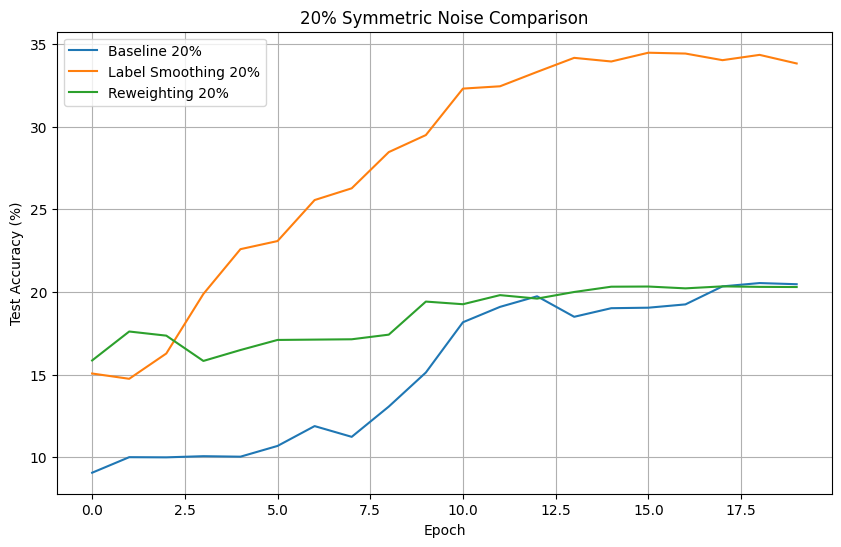

In [40]:
import matplotlib.pyplot as plt

# 20% Noise Comparison
plt.figure(figsize=(10,6))

plt.plot(results_sym20['test_acc'],
         label='Baseline 20%')

plt.plot(results_ls_20['test_acc'],
         label='Label Smoothing 20%')

plt.plot(results_reweight_20['test_acc'],
         label='Reweighting 20%')

plt.xlabel('Epoch')
plt.ylabel('Test Accuracy (%)')
plt.title('20% Symmetric Noise Comparison')
plt.legend()
plt.grid(True)

plt.show()

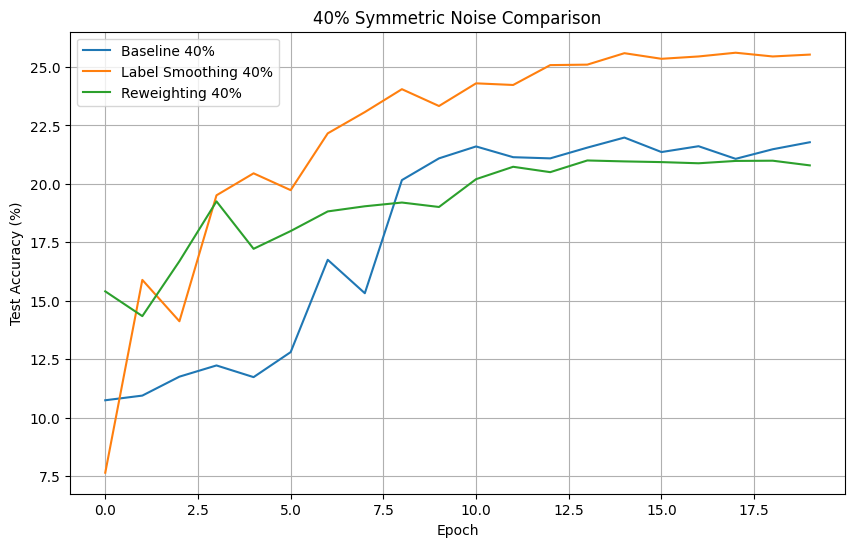

In [41]:
plt.figure(figsize=(10,6))

plt.plot(results_sym40['test_acc'],
         label='Baseline 40%')

plt.plot(results_ls_40['test_acc'],
         label='Label Smoothing 40%')

plt.plot(results_reweight_40['test_acc'],
         label='Reweighting 40%')

plt.xlabel('Epoch')
plt.ylabel('Test Accuracy (%)')
plt.title('40% Symmetric Noise Comparison')
plt.legend()
plt.grid(True)

plt.show()

In [42]:
print("\n" + "="*70)
print("FINAL RESULTS")
print("="*70)

print(f"{'Method':<25} {'20% Noise':<15} {'40% Noise':<15}")
print("-"*70)

print(f"{'Baseline':<25} "
      f"{results_sym20['test_acc'][-1]:<15.2f} "
      f"{results_sym40['test_acc'][-1]:<15.2f}")

print(f"{'Label Smoothing':<25} "
      f"{results_ls_20['test_acc'][-1]:<15.2f} "
      f"{results_ls_40['test_acc'][-1]:<15.2f}")

print(f"{'Sample Reweighting':<25} "
      f"{results_reweight_20['test_acc'][-1]:<15.2f} "
      f"{results_reweight_40['test_acc'][-1]:<15.2f}")

print("="*70)


FINAL RESULTS
Method                    20% Noise       40% Noise      
----------------------------------------------------------------------
Baseline                  20.47           21.78          
Label Smoothing           33.82           25.53          
Sample Reweighting        20.30           20.79          


Co-Teaching inspired approach

In [43]:
class SmallLossTrainer:
    def __init__(self,
                 model,
                 device='cuda',
                 remember_rate=0.8):

        self.model = model.to(device)
        self.device = device
        self.remember_rate = remember_rate

        # IMPORTANT
        self.criterion = nn.CrossEntropyLoss(reduction='none')

    def train_epoch(self, loader, optimizer):

        self.model.train()

        total_loss = 0
        correct = 0
        total = 0

        for inputs, targets, _ in tqdm(loader,
                                       desc='Training',
                                       leave=False):

            inputs = inputs.to(self.device)
            targets = targets.to(self.device)

            optimizer.zero_grad()

            outputs = self.model(inputs)

            # Per-sample losses
            losses = self.criterion(outputs, targets)

            # Number of samples to keep
            num_remember = int(
                self.remember_rate * len(losses)
            )

            # Select small-loss samples
            small_loss_idx = torch.argsort(losses)[:num_remember]

            # Final loss
            loss = losses[small_loss_idx].mean()

            loss.backward()
            optimizer.step()

            total_loss += loss.item()

            _, predicted = outputs.max(1)

            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()

        return total_loss / len(loader), 100. * correct / total

    def test(self, loader):

        self.model.eval()

        correct = 0
        total = 0

        with torch.no_grad():

            for inputs, targets in loader:

                inputs = inputs.to(self.device)
                targets = targets.to(self.device)

                outputs = self.model(inputs)

                _, predicted = outputs.max(1)

                total += targets.size(0)
                correct += predicted.eq(targets).sum().item()

        return 100. * correct / total

In [44]:
def run_smallloss_experiment(noise_type='symmetric',
                             noise_rate=0.2,
                             epochs=20,
                             remember_rate=0.8):

    print(f"\n{'='*60}")
    print(f"Small-Loss Selection")
    print(f"Noise: {noise_type}, rate={noise_rate}")
    print(f"{'='*60}\n")

    # DATA
    train_dataset = QuickNoisyCIFAR10(
        train=True,
        noise_type=noise_type,
        noise_rate=noise_rate,
        subset_size=5000
    )

    test_transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(
            (0.4914, 0.4822, 0.4465),
            (0.2023, 0.1994, 0.2010)
        )
    ])

    test_dataset = torchvision.datasets.CIFAR10(
        root='./data',
        train=False,
        download=True,
        transform=test_transform
    )

    train_loader = torch.utils.data.DataLoader(
        train_dataset,
        batch_size=128,
        shuffle=True,
        num_workers=2
    )

    test_loader = torch.utils.data.DataLoader(
        test_dataset,
        batch_size=128,
        shuffle=False,
        num_workers=2
    )

    # MODEL
    model = get_resnet18()

    trainer = SmallLossTrainer(
        model,
        device='cuda',
        remember_rate=remember_rate
    )

    optimizer = optim.SGD(
        model.parameters(),
        lr=0.1,
        momentum=0.9,
        weight_decay=5e-4
    )

    scheduler = optim.lr_scheduler.MultiStepLR(
        optimizer,
        milestones=[10, 15],
        gamma=0.1
    )

    history = {
        'train_loss': [],
        'train_acc': [],
        'test_acc': []
    }

    for epoch in range(epochs):

        print(f"\nEpoch {epoch+1}/{epochs}")

        train_loss, train_acc = trainer.train_epoch(
            train_loader,
            optimizer
        )

        test_acc = trainer.test(test_loader)

        scheduler.step()

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['test_acc'].append(test_acc)

        print(
            f"Loss: {train_loss:.4f} | "
            f"Train: {train_acc:.2f}% | "
            f"Test: {test_acc:.2f}%"
        )

    print(f"\n✓ Final Test Accuracy: {history['test_acc'][-1]:.2f}%")

    return history

In [45]:
results_smallloss_20 = run_smallloss_experiment(
    noise_type='symmetric',
    noise_rate=0.2,
    epochs=20,
    remember_rate=0.8
)

results_smallloss_40 = run_smallloss_experiment(
    noise_type='symmetric',
    noise_rate=0.4,
    epochs=20,
    remember_rate=0.7
)


Small-Loss Selection
Noise: symmetric, rate=0.2

✓ Taux de bruit réel : 17.84%

Epoch 1/20


Loss: 2.3761 | Train: 12.02% | Test: 13.00%

Epoch 2/20


Loss: 2.1430 | Train: 12.84% | Test: 15.16%

Epoch 3/20


Loss: 2.0940 | Train: 13.24% | Test: 13.02%

Epoch 4/20


Loss: 2.0761 | Train: 14.58% | Test: 16.47%

Epoch 5/20


...

Loss: 1.8018 | Train: 19.28% | Test: 24.25%

Epoch 17/20


Loss: 1.7992 | Train: 19.82% | Test: 24.66%

Epoch 18/20


Loss: 1.7993 | Train: 19.94% | Test: 24.56%

Epoch 19/20


Loss: 1.7839 | Train: 19.40% | Test: 24.64%

Epoch 20/20


Loss: 1.7948 | Train: 19.82% | Test: 24.51%

✓ Final Test Accuracy: 24.51%


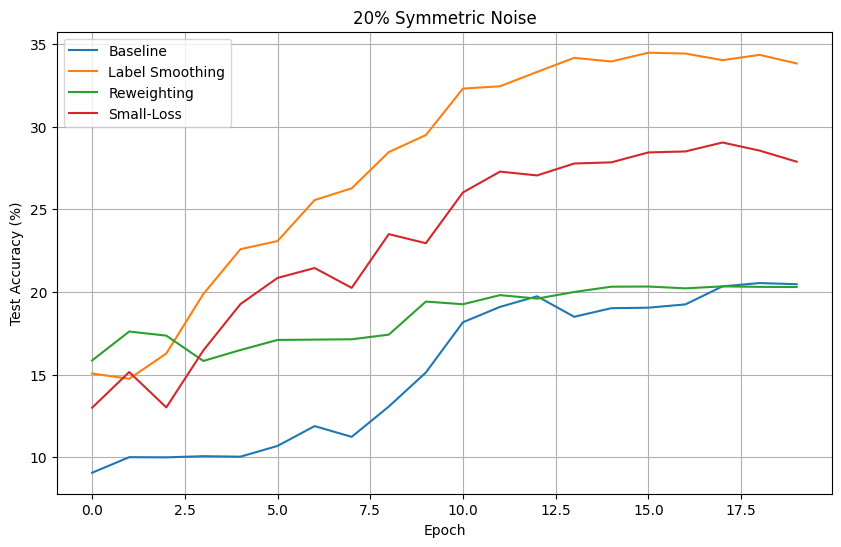

In [46]:
# 20% Noise
plt.figure(figsize=(10,6))

plt.plot(results_sym20['test_acc'],
         label='Baseline')

plt.plot(results_ls_20['test_acc'],
         label='Label Smoothing')

plt.plot(results_reweight_20['test_acc'],
         label='Reweighting')

plt.plot(results_smallloss_20['test_acc'],
         label='Small-Loss')

plt.xlabel('Epoch')
plt.ylabel('Test Accuracy (%)')
plt.title('20% Symmetric Noise')
plt.legend()
plt.grid(True)

plt.show()

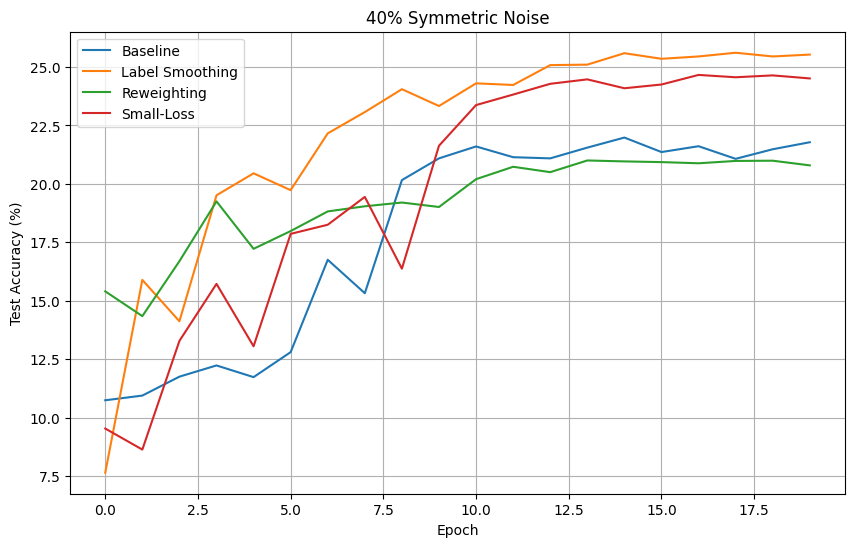

In [47]:
# 40% Noise
plt.figure(figsize=(10,6))

plt.plot(results_sym40['test_acc'],
         label='Baseline')

plt.plot(results_ls_40['test_acc'],
         label='Label Smoothing')

plt.plot(results_reweight_40['test_acc'],
         label='Reweighting')

plt.plot(results_smallloss_40['test_acc'],
         label='Small-Loss')

plt.xlabel('Epoch')
plt.ylabel('Test Accuracy (%)')
plt.title('40% Symmetric Noise')
plt.legend()
plt.grid(True)

plt.show()

In [48]:
print("\n" + "="*80)
print("FINAL RESULTS")
print("="*80)

print(f"{'Method':<30} {'20% Noise':<15} {'40% Noise':<15}")
print("-"*80)

print(f"{'Baseline':<30}"
      f"{results_sym20['test_acc'][-1]:<15.2f}"
      f"{results_sym40['test_acc'][-1]:<15.2f}")

print(f"{'Label Smoothing':<30}"
      f"{results_ls_20['test_acc'][-1]:<15.2f}"
      f"{results_ls_40['test_acc'][-1]:<15.2f}")

print(f"{'Sample Reweighting':<30}"
      f"{results_reweight_20['test_acc'][-1]:<15.2f}"
      f"{results_reweight_40['test_acc'][-1]:<15.2f}")

print(f"{'Small-Loss Selection':<30}"
      f"{results_smallloss_20['test_acc'][-1]:<15.2f}"
      f"{results_smallloss_40['test_acc'][-1]:<15.2f}")

print("="*80)


FINAL RESULTS
Method                         20% Noise       40% Noise      
--------------------------------------------------------------------------------
Baseline                      20.47          21.78          
Label Smoothing               33.82          25.53          
Sample Reweighting            20.30          20.79          
Small-Loss Selection          27.88          24.51          
